# Contextual Adaptive Cross-Modal Attention Fusion (CA-CMAF)
## Multimodal Sentiment Analysis — MVSA-Single

**Arsitektur:** BERT + VGG-16 + Cross-Modal Attention + Adaptive Gate Fusion

**Dataset:** `D:/MVSA_SINGLE`


In [1]:

# ============================================================
# CONFIGURATION
# ============================================================

class CFG:

    # =========================
    # PATH
    # =========================
    ROOT_DIR = r"D:/MVSA_SINGLE"
    DATA_DIR = r"D:/MVSA_SINGLE/data"
    LABEL_PATH = r"D:/MVSA_SINGLE/labelResultAllFinal.txt"


    # =========================
    # EARLY STOPPING
    # =========================
    PATIENCE = 8

    # =========================
    # SPLIT
    # =========================
    TEST_SIZE = 0.15
    VAL_SIZE = 0.15

    # =========================
    # DEVICE
    # =========================
    DEVICE = "cuda"


In [2]:
import pandas as pd
import os
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=',')
df.columns = ["id", "text_label", "image_label", "final_label"]

def is_valid(row):

    if row["text_label"] == "positive" and row["image_label"] == "negative":
        return False

    if row["text_label"] == "negative" and row["image_label"] == "positive":
        return False

    return True

df = df[df.apply(is_valid, axis=1)]
df = df.reset_index(drop=True)

print(f"Dataset size after filtering: {len(df)}")

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

df["label"] = df["final_label"].map(label_map)

# Load text file dengan better error handling
def load_text(sample_id):
    path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")

    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

    for encoding in encodings:
        try:
            with open(path, "r", encoding=encoding) as f:
                text = f.read().strip()
                if text:  # Jika text berhasil dibaca dan tidak kosong
                    return text
        except FileNotFoundError:
            continue
        except Exception as e:
            continue

    # Jika semua encoding gagal atau file tidak ada
    return ""

# Track failed samples for debugging
failed_samples = []

df["text"] = df["id"].apply(load_text)

# Hitung empty text
empty_text_count = (df["text"] == "").sum()
print(f"\n{'='*60}")
print(f"PREPROCESSING STATISTICS:")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Samples with EMPTY text: {empty_text_count}")
print(f"Samples with VALID text: {len(df) - empty_text_count}")
print(f"Percentage of empty text: {(empty_text_count/len(df)*100):.2f}%")
print(f"{'='*60}\n")

if empty_text_count > 0:
    print("IDs with empty text:")
    empty_ids = df[df["text"] == ""]["id"].tolist()
    for idx in empty_ids[:10]:  # Show first 10
        print(f"  - {idx}")
    if len(empty_ids) > 10:
        print(f"  ... and {len(empty_ids) - 10} more")
    print()

# image path
df["image_path"] = df["id"].apply(
    lambda x: os.path.join(CFG.DATA_DIR, f"{x}.jpg")
)

df.head()


Dataset size after filtering: 4511

PREPROCESSING STATISTICS:
Total samples: 4511
Samples with EMPTY text: 0
Samples with VALID text: 4511
Percentage of empty text: 0.00%



,id,text_label,image_label,final_label,label,text,image_path
0,1,neutral,positive,positive,2,How I feel today #legday #jelly #aching #gym,D:/MVSA_SINGLE/data\1.jpg
1,2,neutral,positive,positive,2,grattis min griskulting!!!???? va bara tvungen...,D:/MVSA_SINGLE/data\2.jpg
2,3,neutral,positive,positive,2,RT @polynminion: The moment I found my favouri...,D:/MVSA_SINGLE/data\3.jpg
3,4,positive,positive,positive,2,#escort We have a young and energetic team and...,D:/MVSA_SINGLE/data\4.jpg
4,5,positive,positive,positive,2,"RT @chrisashaffer: Went to SSC today to be a ""...",D:/MVSA_SINGLE/data\5.jpg


In [3]:

# ============================================================
# HYPERPARAMETERS (tambahan ke CFG)
# ============================================================

CFG.BATCH_SIZE = 32
CFG.EPOCHS = 50
CFG.LR = 1e-4
CFG.WEIGHT_DECAY = 1e-3
CFG.LATENT_DIM = 512
CFG.NUM_HEADS = 8
CFG.DROPOUT = 0.4
CFG.MAX_LEN = 128
CFG.IMG_SIZE = 128
CFG.NUM_CLASSES = 3

# ============================================================
# LIBRARY IMPORTS
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from transformers import BertModel, BertTokenizer
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tqdm import tqdm
import numpy as np
import random
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


C:\Users\Residensi ADW\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

# ============================================================
# IMAGE TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ============================================================
# TOKENIZER
# ============================================================

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# ============================================================
# MULTIMODAL DATASET CLASS
# ============================================================

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, transform, max_len=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        text = str(row['text'])
        image_path = row['image_path']
        label = int(row['label'])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        try:
            image = Image.open(image_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (CFG.IMG_SIZE, CFG.IMG_SIZE), color=(128, 128, 128))

        image = self.transform(image)

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'image': image,
            'label': torch.tensor(label, dtype=torch.long)
        }


In [5]:

# ============================================================
# TRAIN / VAL / TEST SPLIT
# ============================================================

dataset_size = len(df)
test_size = int(CFG.TEST_SIZE * dataset_size)
val_size = int(CFG.VAL_SIZE * dataset_size)
train_size = dataset_size - val_size - test_size

train_split, val_split, test_split = random_split(
    df, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_df = df.iloc[train_split.indices].copy()
val_df = df.iloc[val_split.indices].copy()
test_df = df.iloc[test_split.indices].copy()

train_dataset = MultimodalDataset(train_df, tokenizer, train_transform, CFG.MAX_LEN)
val_dataset = MultimodalDataset(val_df, tokenizer, val_transform, CFG.MAX_LEN)
test_dataset = MultimodalDataset(test_df, tokenizer, val_transform, CFG.MAX_LEN)

print(f"Train samples   : {len(train_dataset)}")
print(f"Val samples     : {len(val_dataset)}")
print(f"Test samples    : {len(test_dataset)}")

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0)


Train samples   : 3159
Val samples     : 676
Test samples    : 676


In [6]:

# ============================================================
# CA-CMAF MODEL
# Contextual Adaptive Cross-Modal Attention Fusion
# ============================================================

class CrossModalAttention(nn.Module):
    """
    Multi-head element-wise gated cross-modal attention.
    Dirancang untuk single feature vectors (bukan sequences).

    Mekanisme per head:
      Q = proyeksi fitur teks  →  K = proyeksi fitur visual
      gate = sigmoid(Q_h * K_h / sqrt(d_head))   ← element-wise gating
      cross = gate * V_h                          ← visual digate oleh teks

    Berbeda dari nn.MultiheadAttention yang memerlukan seq_len > 1.
    """

    def __init__(self, dim=512, num_heads=8, dropout=0.1):
        super().__init__()
        assert dim % num_heads == 0, f"dim ({dim}) harus habis dibagi num_heads ({num_heads})"
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** 0.5

        self.W_q = nn.Linear(dim, dim)
        self.W_k = nn.Linear(dim, dim)
        self.W_v = nn.Linear(dim, dim)
        self.W_o = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)

    def forward(self, Q, K, V):
        """
        Args:
            Q: teks features    (batch, dim)
            K: visual features  (batch, dim)
            V: visual features  (batch, dim)

        Returns:
            cross-modal representation (batch, dim)
        """
        batch = Q.size(0)

        Q = self.W_q(Q).view(batch, self.num_heads, self.head_dim)
        K = self.W_k(K).view(batch, self.num_heads, self.head_dim)
        V = self.W_v(V).view(batch, self.num_heads, self.head_dim)

        similarity = Q * K / self.scale
        gate = torch.sigmoid(similarity)
        gate = self.dropout(gate)

        cross = gate * V
        cross = cross.view(batch, -1)
        cross = self.W_o(cross)

        return self.norm(cross)


class CA_CMAF(nn.Module):
    """
    Contextual Adaptive Cross-Modal Attention Fusion (CA-CMAF)

    Arsitektur:
      1. Text Pipeline  : BERT base-uncased (fine-tuned) -> Proyeksi 512-d
      2. Visual Pipeline: VGG-16 (frozen) -> Proyeksi 512-d
      3. Cross-Modal Attention: Multi-head Attention (Q=text, K=V=visual)
      4. Adaptive Gate Fusion: Gating mechanism untuk fusi adaptif
      5. Classifier: Dense layers -> 3 kelas sentimen
    """

    def __init__(self, latent_dim=512, num_heads=8, num_classes=3, dropout=0.4):
        super(CA_CMAF, self).__init__()

        self.latent_dim = latent_dim

        # ============================================================
        # 1. TEXT FEATURE EXTRACTION (BERT)
        #    Pre-trained bert-base-uncased -> [CLS] pooled output
        #    Dense(768 -> 512) -> ReLU -> BatchNorm
        # ============================================================

        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # Freeze ALL BERT parameters (109M parameters)
        # Dataset kecil (~3159 sampel) → full freeze cegah overfitting
        for param in self.bert.parameters():
            param.requires_grad = False

        self.text_proj = nn.Sequential(
            nn.Linear(768, latent_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(latent_dim)
        )

        # ============================================================
        # 2. VISUAL FEATURE EXTRACTION (VGG-16, FROZEN)
        #    Pre-trained VGG-16 features -> Global Average Pooling
        #    Dense(512 -> 512) -> ReLU -> BatchNorm
        #    Note: semua parameter VGG di-freeze (requires_grad=False)
        # ============================================================

        vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        self.vgg_features = vgg16.features

        for param in self.vgg_features.parameters():
            param.requires_grad = False

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.visual_proj = nn.Sequential(
            nn.Linear(512, latent_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(latent_dim)
        )

        # ============================================================
        # 3. CROSS-MODAL ATTENTION (CMA)
        #    Multi-head element-wise gated attention
        #    Query (Q) = fitur teks yang telah diproyeksikan
        #    Key (K)   = fitur visual yang telah diproyeksikan
        #    Value (V) = fitur visual yang telah diproyeksikan
        #    gate = sigmoid(Q_h * K_h) → cross = gate * V_h
        #    Menghasilkan representasi cross-modal
        # ============================================================

        self.cross_attn = CrossModalAttention(
            dim=latent_dim,
            num_heads=num_heads,
            dropout=dropout
        )

        # ============================================================
        # 4. ADAPTIVE LEARNING & ATTENTION-BASED FUSION
        #    Gating mechanism: menghitung bobot atensi (alpha)
        #    secara dinamis untuk mengevaluasi signifikansi
        #    tiap modalitas, kemudian menggabungkan fitur
        #    cross-modal secara adaptif dengan fitur visual asli.
        #    fused = alpha * cross_modal + (1-alpha) * visual
        # ============================================================

        self.fusion_gate = nn.Sequential(
            nn.Linear(latent_dim * 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # ============================================================
        # 5. SENTIMENT CLASSIFIER
        #    Dense layers dengan Dropout 0.4 untuk regularisasi
        #    Output: 3 kelas (negative, neutral, positive)
        # ============================================================

        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, image):
        """
        Forward pass CA-CMAF.

        Args:
            input_ids      : tokenized text input  (batch, seq_len)
            attention_mask : attention mask        (batch, seq_len)
            image          : image tensor          (batch, 3, 128, 128)

        Returns:
            logits         : raw logits            (batch, num_classes)
        """

        # ---- 1. Text Pipeline ----

        bert_output = self.bert(input_ids=input_ids,
                                attention_mask=attention_mask)

        cls_token = bert_output.pooler_output

        text_feat = self.text_proj(cls_token)

        # ---- 2. Visual Pipeline ----

        visual_feat_maps = self.vgg_features(image)

        visual_gap = self.avgpool(visual_feat_maps)

        visual_flat = visual_gap.view(visual_gap.size(0), -1)

        visual_feat = self.visual_proj(visual_flat)

        # ---- 3. Cross-Modal Attention ----

        cross_modal = self.cross_attn(text_feat, visual_feat, visual_feat)

        # ---- 4. Adaptive Gate Fusion ----

        concat = torch.cat([cross_modal, visual_feat], dim=-1)

        alpha = self.fusion_gate(concat)

        fused = alpha * cross_modal + (1.0 - alpha) * visual_feat

        # ---- 5. Classification ----

        logits = self.classifier(fused)

        return logits


In [7]:

# ============================================================
# INSTANTIATE MODEL
# ============================================================

model = CA_CMAF(
    latent_dim=CFG.LATENT_DIM,
    num_heads=CFG.NUM_HEADS,
    num_classes=CFG.NUM_CLASSES,
    dropout=CFG.DROPOUT
)

model = model.to(CFG.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Frozen parameters     : {total_params - trainable_params:,}")

# ============================================================
# OPTIMIZER & LOSS FUNCTION
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY
)

# Class weights atasi imbalance:
# Weight = total / (num_classes * count_per_class)

from collections import Counter

counts = Counter(train_dataset.dataframe['label'].tolist())
total = sum(counts.values())

class_weights = torch.tensor(
    [total / (CFG.NUM_CLASSES * counts[i]) for i in range(CFG.NUM_CLASSES)],
    dtype=torch.float
).to(CFG.DEVICE)

print(f"Training class distribution: {dict(counts)}")
print(f"Class weights              : {class_weights.tolist()}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

# ============================================================
# LEARNING RATE SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.EPOCHS, eta_min=1e-6
)

# ============================================================
# EARLY STOPPING TRACKER
# ============================================================

best_val_acc = 0.0
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3857.95it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Residensi ADW/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 113MB/

Total parameters      : 126,201,924
Trainable parameters  : 111,487,236
Frozen parameters     : 14,714,688


In [8]:

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(1, CFG.EPOCHS + 1):

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CFG.EPOCHS} [Train]")
    for batch in train_pbar:
        input_ids = batch['input_ids'].to(CFG.DEVICE)
        attention_mask = batch['attention_mask'].to(CFG.DEVICE)
        images = batch['image'].to(CFG.DEVICE)
        labels = batch['label'].to(CFG.DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{CFG.EPOCHS} [Val]  ")
    with torch.no_grad():
        for batch in val_pbar:
            input_ids = batch['input_ids'].to(CFG.DEVICE)
            attention_mask = batch['attention_mask'].to(CFG.DEVICE)
            images = batch['image'].to(CFG.DEVICE)
            labels = batch['label'].to(CFG.DEVICE)

            logits = model(input_ids, attention_mask, images)
            loss = criterion(logits, labels)
            val_loss += loss.item()

            preds = torch.argmax(logits, dim=-1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

            val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds) * 100
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    # ---- LOGGING ----
    print(f"Epoch {epoch:2d}/{CFG.EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

    # ---- SCHEDULER STEP ----
    scheduler.step()

    # ---- EARLY STOPPING & CHECKPOINT ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model_ca_cmaf.pt')
        print(f"  >> Best model saved (Acc: {val_acc:.2f}%)")
    else:
        patience_counter += 1
        print(f"  >> Patience: {patience_counter}/{CFG.PATIENCE}")
        if patience_counter >= CFG.PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break

print(f"\n{'='*60}")
print(f"Training completed. Best Val Accuracy: {best_val_acc:.2f}%")
print(f"{'='*60}")


Epoch 1/50 [Val]  : 100%|██████████| 22/22 [00:16<00:00,  1.30it/s, loss=0.4584]


Epoch  1/50 | Train Loss: 0.9838 | Val Loss: 0.8208 | Val Acc: 61.54%
  >> Best model saved (Acc: 61.54%)


Epoch 2/50 [Val]  : 100%|██████████| 22/22 [00:08<00:00,  2.71it/s, loss=0.4127]


Epoch  2/50 | Train Loss: 0.8379 | Val Loss: 0.7779 | Val Acc: 64.50%
  >> Best model saved (Acc: 64.50%)


Epoch 3/50 [Val]  : 100%|██████████| 22/22 [00:08<00:00,  2.67it/s, loss=0.4136]


...

Epoch 11/50 | Train Loss: 0.5167 | Val Loss: 0.9436 | Val Acc: 63.17%
  >> Patience: 6/8


Epoch 12/50 [Val]  : 100%|██████████| 22/22 [00:08<00:00,  2.64it/s, loss=0.0701]


Epoch 12/50 | Train Loss: 0.4898 | Val Loss: 1.0221 | Val Acc: 61.98%
  >> Patience: 7/8


Epoch 13/50 [Val]  : 100%|██████████| 22/22 [00:08<00:00,  2.59it/s, loss=0.0866]

Epoch 13/50 | Train Loss: 0.4616 | Val Loss: 1.0321 | Val Acc: 62.43%
  >> Patience: 8/8

Early stopping triggered at epoch 13

Training completed. Best Val Accuracy: 68.20%


In [9]:

# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(torch.load('best_model_ca_cmaf.pt', map_location=CFG.DEVICE))
model = model.to(CFG.DEVICE)
model.eval()

# ============================================================
# TEST SET EVALUATION
# ============================================================

test_loss = 0.0
test_preds, test_labels = [], []

test_pbar = tqdm(test_loader, desc="Test Evaluation")
with torch.no_grad():
    for batch in test_pbar:
        input_ids = batch['input_ids'].to(CFG.DEVICE)
        attention_mask = batch['attention_mask'].to(CFG.DEVICE)
        images = batch['image'].to(CFG.DEVICE)
        labels = batch['label'].to(CFG.DEVICE)

        logits = model(input_ids, attention_mask, images)
        loss = criterion(logits, labels)
        test_loss += loss.item()

        preds = torch.argmax(logits, dim=-1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_acc = accuracy_score(test_labels, test_preds) * 100
macro_f1 = f1_score(test_labels, test_preds, average='macro')
weighted_f1 = f1_score(test_labels, test_preds, average='weighted')

print(f"\n{'='*60}")
print(f"TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test Loss       : {avg_test_loss:.4f}")
print(f"Test Accuracy   : {test_acc:.4f}%")
print(f"Macro F1-Score  : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")
print(f"{'='*60}\n")

print("\nClassification Report:")
print(classification_report(test_labels, test_preds,
                            target_names=['negative', 'neutral', 'positive']))

print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels, test_preds)
print(cm)


Test Evaluation: 100%|██████████| 22/22 [00:17<00:00,  1.24it/s]


TEST SET RESULTS
Test Loss       : 0.8201
Test Accuracy   : 63.6095%
Macro F1-Score  : 0.4792
Weighted F1     : 0.5992


Classification Report:
              precision    recall  f1-score   support

    negative       0.50      0.33      0.40       202
     neutral       0.56      0.19      0.28        75
    positive       0.67      0.88      0.76       399

    accuracy                           0.64       676
   macro avg       0.58      0.46      0.48       676
weighted avg       0.61      0.64      0.60       676


Confusion Matrix:
[[ 66   6 130]
 [ 22  14  39]
 [ 44   5 350]]


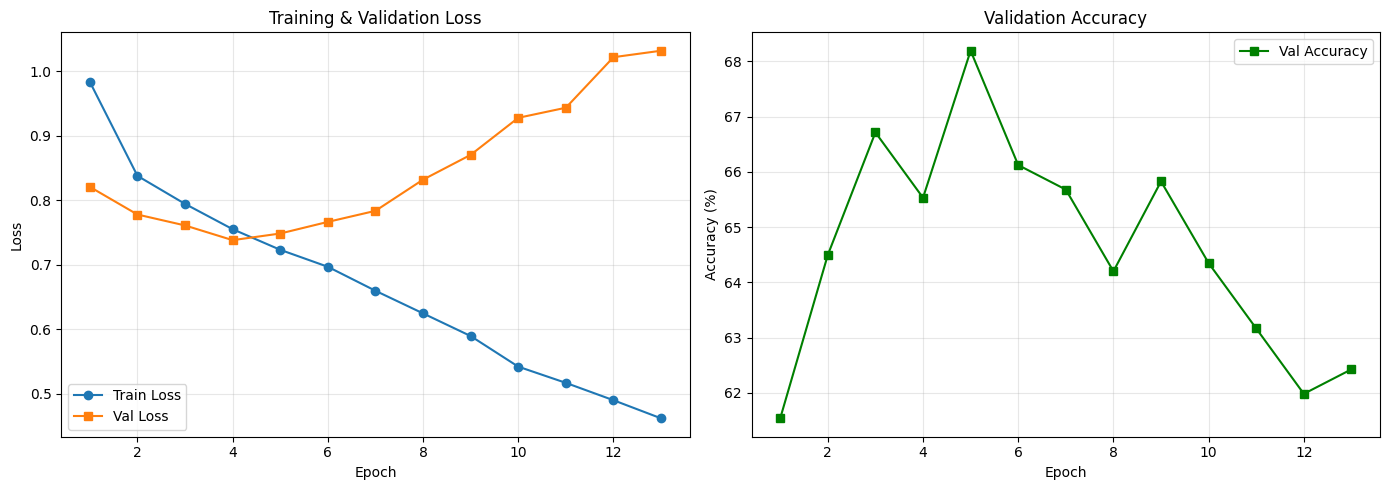

In [10]:

# ============================================================
# TRAINING CURVES
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
ax1.plot(epochs_range, history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['val_acc'], label='Val Accuracy', marker='s', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
